In [1]:
import matplotlib.pyplot as plt
import os
import re

os.makedirs('../reports/charts', exist_ok=True)
if not hasattr(plt, '_original_show'):
    plt._original_show = plt.show
    plt._plot_counter = 1

    def _custom_show(*args, **kwargs):
        title = plt.gca().get_title()
        if title:
            clean_title = re.sub(r'[^\w\-_\. ]', '_', title).strip().replace(' ', '_')
            filename = f'../reports/charts/{clean_title}_{plt._plot_counter}.png'
        else:
            filename = f'../reports/charts/04_eda_figure_{plt._plot_counter}.png'
            
        try:
            plt.savefig(filename, bbox_inches='tight')
            print(f"Saved chart to {filename}")
        except Exception as e:
            print(f"Warning: Could not save figure {filename}: {e}")
            
        plt._plot_counter += 1
        plt._original_show(*args, **kwargs)

    plt.show = _custom_show


# 5.0 Exploratory Data Analysis (EDA)

This notebook builds all derived features on top of the cleaned datasets produced in `02_data_cleanup_and_filteration.ipynb`.

**Reference files used:**
- `../data/raw/state_crosswalk.csv` — canonical state codes, valid-from/to years, bifurcation history  
- `../data/raw/state_name_audit.csv` — raw state names identified during the audit pass  
- `../data/raw/state_name_variants.csv` — variant → canonical name lookup (also used in cleanup notebook)

**Filtered inputs expected:**
```
../data/interim/clean_election_results_1951_2019.csv
../data/interim/clean_loksabha_1962_2019.csv
../data/interim/clean_election_results_2024.csv
../data/interim/clean_ref_party_master.csv
../data/interim/features_dataset.csv
```

---
## Imports & Data Loading

In [2]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

In [3]:
# ─── Reference files ────────────────────────────────────────────────────────
state_crosswalk     = pd.read_csv('../data/raw/state_crosswalk.csv')
state_name_audit    = pd.read_csv('../data/raw/state_name_audit.csv')
state_name_variants = pd.read_csv('../data/raw/state_name_variants.csv')

# ─── Cleaned election datasets (output of cleanup notebook) ─────────────────
df_1951_2019 = pd.read_csv('../data/interim/clean_election_results_1951_2019.csv')
df_loksabha  = pd.read_csv('../data/interim/clean_loksabha_1962_2019.csv')
df_2024      = pd.read_csv('../data/interim/clean_election_results_2024.csv')
df_party     = pd.read_csv('../data/interim/clean_ref_party_master.csv')
df_features  = pd.read_csv('../data/interim/features_dataset.csv')

print('Loaded datasets:')
print(f'  clean_election_results_1951_2019 : {df_1951_2019.shape}')
print(f'  clean_loksabha_1962_2019         : {df_loksabha.shape}')
print(f'  clean_election_results_2024      : {df_2024.shape}')
print(f'  clean_ref_party_master           : {df_party.shape}')
print(f'  df_features                      : {df_features.shape}')

Loaded datasets:
  clean_election_results_1951_2019 : (89840, 19)
  clean_loksabha_1962_2019         : (8047, 15)
  clean_election_results_2024      : (8902, 16)
  clean_ref_party_master           : (10153, 27)
  df_features                      : (89840, 30)


## 5.1 Temporal analysis

### 5.1.1 Vote‑share trends by party/alliance

The temporal evolution of aggregate vote shares for major political alliances (e.g., NDA, UPA/INDIA) across national elections, visualized over distinct historical eras.Formula:$$S_{A,t} = \frac{\sum_{i \in A} V_{i,t}}{\text{Total Valid Votes}_t} \times 100$$(Where $S_{A,t}$ is the aggregate share of alliance $A$ at time $t$, and $V_{i,t}$ represents the votes of constituent party $i$)

Saved chart to ../reports/charts/Alliance_Vote_Share_Trends_by_Political_Era_1.png


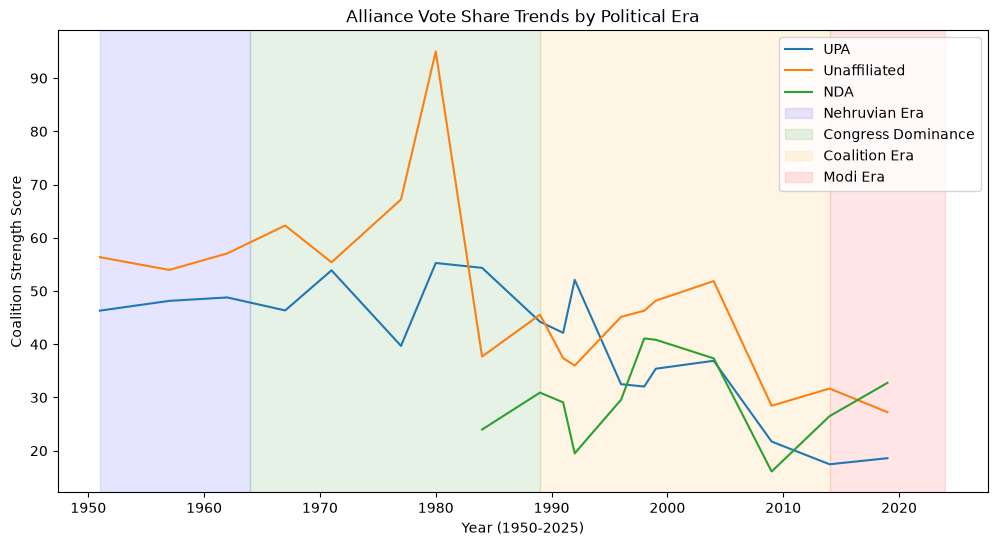

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by year and alliance to get average coalition strength
trend_df = df_features.groupby(['election_year_clean', 'alliance'])['coalition_strength_score'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_df, x='election_year_clean', y='coalition_strength_score', hue='alliance')

# Shade eras
plt.axvspan(1951, 1964, color='blue', alpha=0.1, label='Nehruvian Era')
plt.axvspan(1964, 1989, color='green', alpha=0.1, label='Congress Dominance')
plt.axvspan(1989, 2014, color='orange', alpha=0.1, label='Coalition Era')
plt.axvspan(2014, 2024, color='red', alpha=0.1, label='Modi Era')

plt.title('Alliance Vote Share Trends by Political Era')
plt.xlabel("Year (1950-2025)")
plt.ylabel("Coalition Strength Score")
plt.legend()
plt.show()

### 5.1.2 Turnout trends (national and by region)

The measurement of voter participation, calculated as the percentage of eligible electors who cast their vote, analyzed both nationally and across geographic regions.Formula:$$T_t = \left( \frac{\sum \text{Votes}_t}{\sum \text{Electors}_t} \right) \times 100$$

Saved chart to ../reports/charts/National_Voter_Turnout_Trend__1962-2019__2.png


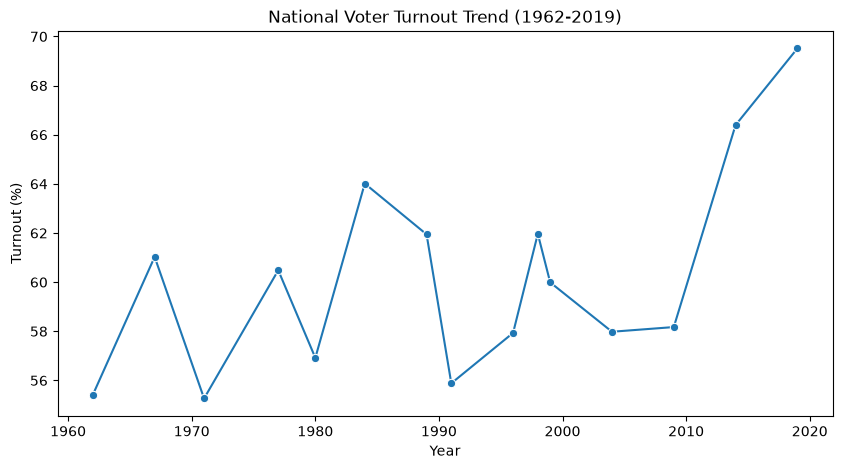

In [5]:
# Group by year to calculate national turnout
turnout_df = df_loksabha.groupby('year').apply(
    lambda x: (x['votes'].sum() / x['electors'].sum()) * 100
).reset_index(name='national_turnout')

plt.figure(figsize=(10, 5))
sns.lineplot(data=turnout_df, x='year', y='national_turnout', marker='o')
plt.title('National Voter Turnout Trend (1962-2019)')
plt.ylabel('Turnout %')
plt.xlabel("Year")
plt.ylabel("Turnout (%)")
plt.show()

### 5.1.3 Seat‑vote disproportionality

A metric (the Gallagher Index) that quantifies the difference between the percentage of votes a party receives and the percentage of legislative seats it is awarded.Formula:$$G = \sqrt{\frac{1}{2} \sum_{i=1}^{n} (V_i - S_i)^2}$$(Where $V_i$ is vote share % and $S_i$ is seat share % for party $i$)

In [6]:
# Calculate total seats per year 
total_seats = df_features[df_features['is_winner'] == 1].groupby('election_year_clean').size()

# Calculate party wins per year 
party_wins = df_features[df_features['is_winner'] == 1].groupby(['election_year_clean', 'party']).size()
seat_share = (party_wins / total_seats * 100).reset_index(name='seat_share_pct')

# Get national vote share per party (approximation via sum of votes) 

# Assuming df_features has total national votes pre-calculated or calculable
party_votes = df_features.groupby(['election_year_clean', 'party'])['votes_received'].sum()
total_votes = df_features.groupby('election_year_clean')['votes_received'].sum()
vote_share = (party_votes / total_votes * 100).reset_index(name='nat_vote_share_pct')

# Merge and calculate Gallagher Index
disprop_df = pd.merge(seat_share, vote_share, on=['election_year_clean', 'party'])
disprop_df['diff_sq'] = (disprop_df['seat_share_pct'] - disprop_df['nat_vote_share_pct']) ** 2

gallagher_index = disprop_df.groupby('election_year_clean')['diff_sq'].sum().apply(lambda x: np.sqrt(x / 2)).reset_index(name='gallagher_index')
gallagher_index

,election_year_clean,gallagher_index
0,1951,22.564467
1,1957,20.391892
2,1962,21.722999
3,1967,10.483423
4,1971,18.650226
5,1977,10.099975
6,1980,16.684056
7,1984,21.922499
8,1989,7.956164
9,1991,7.122181


___

## 5.2 Spatial analysis

### 5.2.1 State‑wise dominance heatmaps

A visual matrix showing which political party secured the highest aggregate vote share or won the most seats in a given state over successive elections.Formula:$$W_{s,t} = \arg\max_{P} \sum_{i \in s} \text{Seats}_{P,i,t}$$

In [7]:
# Count wins by party per state per year 
wins_df = df_features[df_features['is_winner'] == 1]
state_party_wins = wins_df.groupby(['state_canonical', 'election_year_clean', 'party']).size().reset_index(name='wins')

# Find dominant party per state/year
idx = state_party_wins.groupby(['state_canonical', 'election_year_clean'])['wins'].idxmax()
dominant_parties = state_party_wins.loc[idx]

# Pivot for heatmap
heatmap_data = dominant_parties.pivot(index='state_canonical', columns='election_year_clean', values='party')

# Requires numeric mapping for sns.heatmap, usually done via converting categorical to codes
heatmap_data

election_year_clean,1951,1957,1962,1967,1971,1977,1980,1984,1989,1991,1992,1996,1998,1999,2004,2009,2014,2019
state_canonical,,,,,,,,,,,,,,,,,,
ANDAMAN AND NICOBAR ISLANDS,NaN,NaN,NaN,NaN,INC,INC,INC(I),INC,INC,INC,NaN,INC,INC,BJP,INC,BJP,BJP,INC
ARUNACHAL PRADESH,NaN,NaN,NaN,NaN,NaN,INC,INC(I),INC,INC,INC,NaN,IND,AC,INC,BJP,NaN,NaN,NaN
Ajmer,INC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Andaman And Nicobar Islands,NaN,NaN,NaN,INC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Andhra Pradesh,NaN,INC,INC,INC,INC,INC,INC(I),TDP,INC,INC,NaN,INC,INC,TDP,INC,INC,TDP,YSRCP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tripura,CPI,CPI,CPI,INC,CPM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CPM,CPM,BJP
UTTARANCHAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BJP,NaN,NaN,NaN
Uttar Pradesh,INC,INC,INC,INC,INC,BLD,INC(I),INC,JD,BJP,NaN,BJP,BJP,BJP,SP,SP,BJP,BJP


Saved chart to ../reports/charts/Dominant_Party_per_State_per_Year_3.png


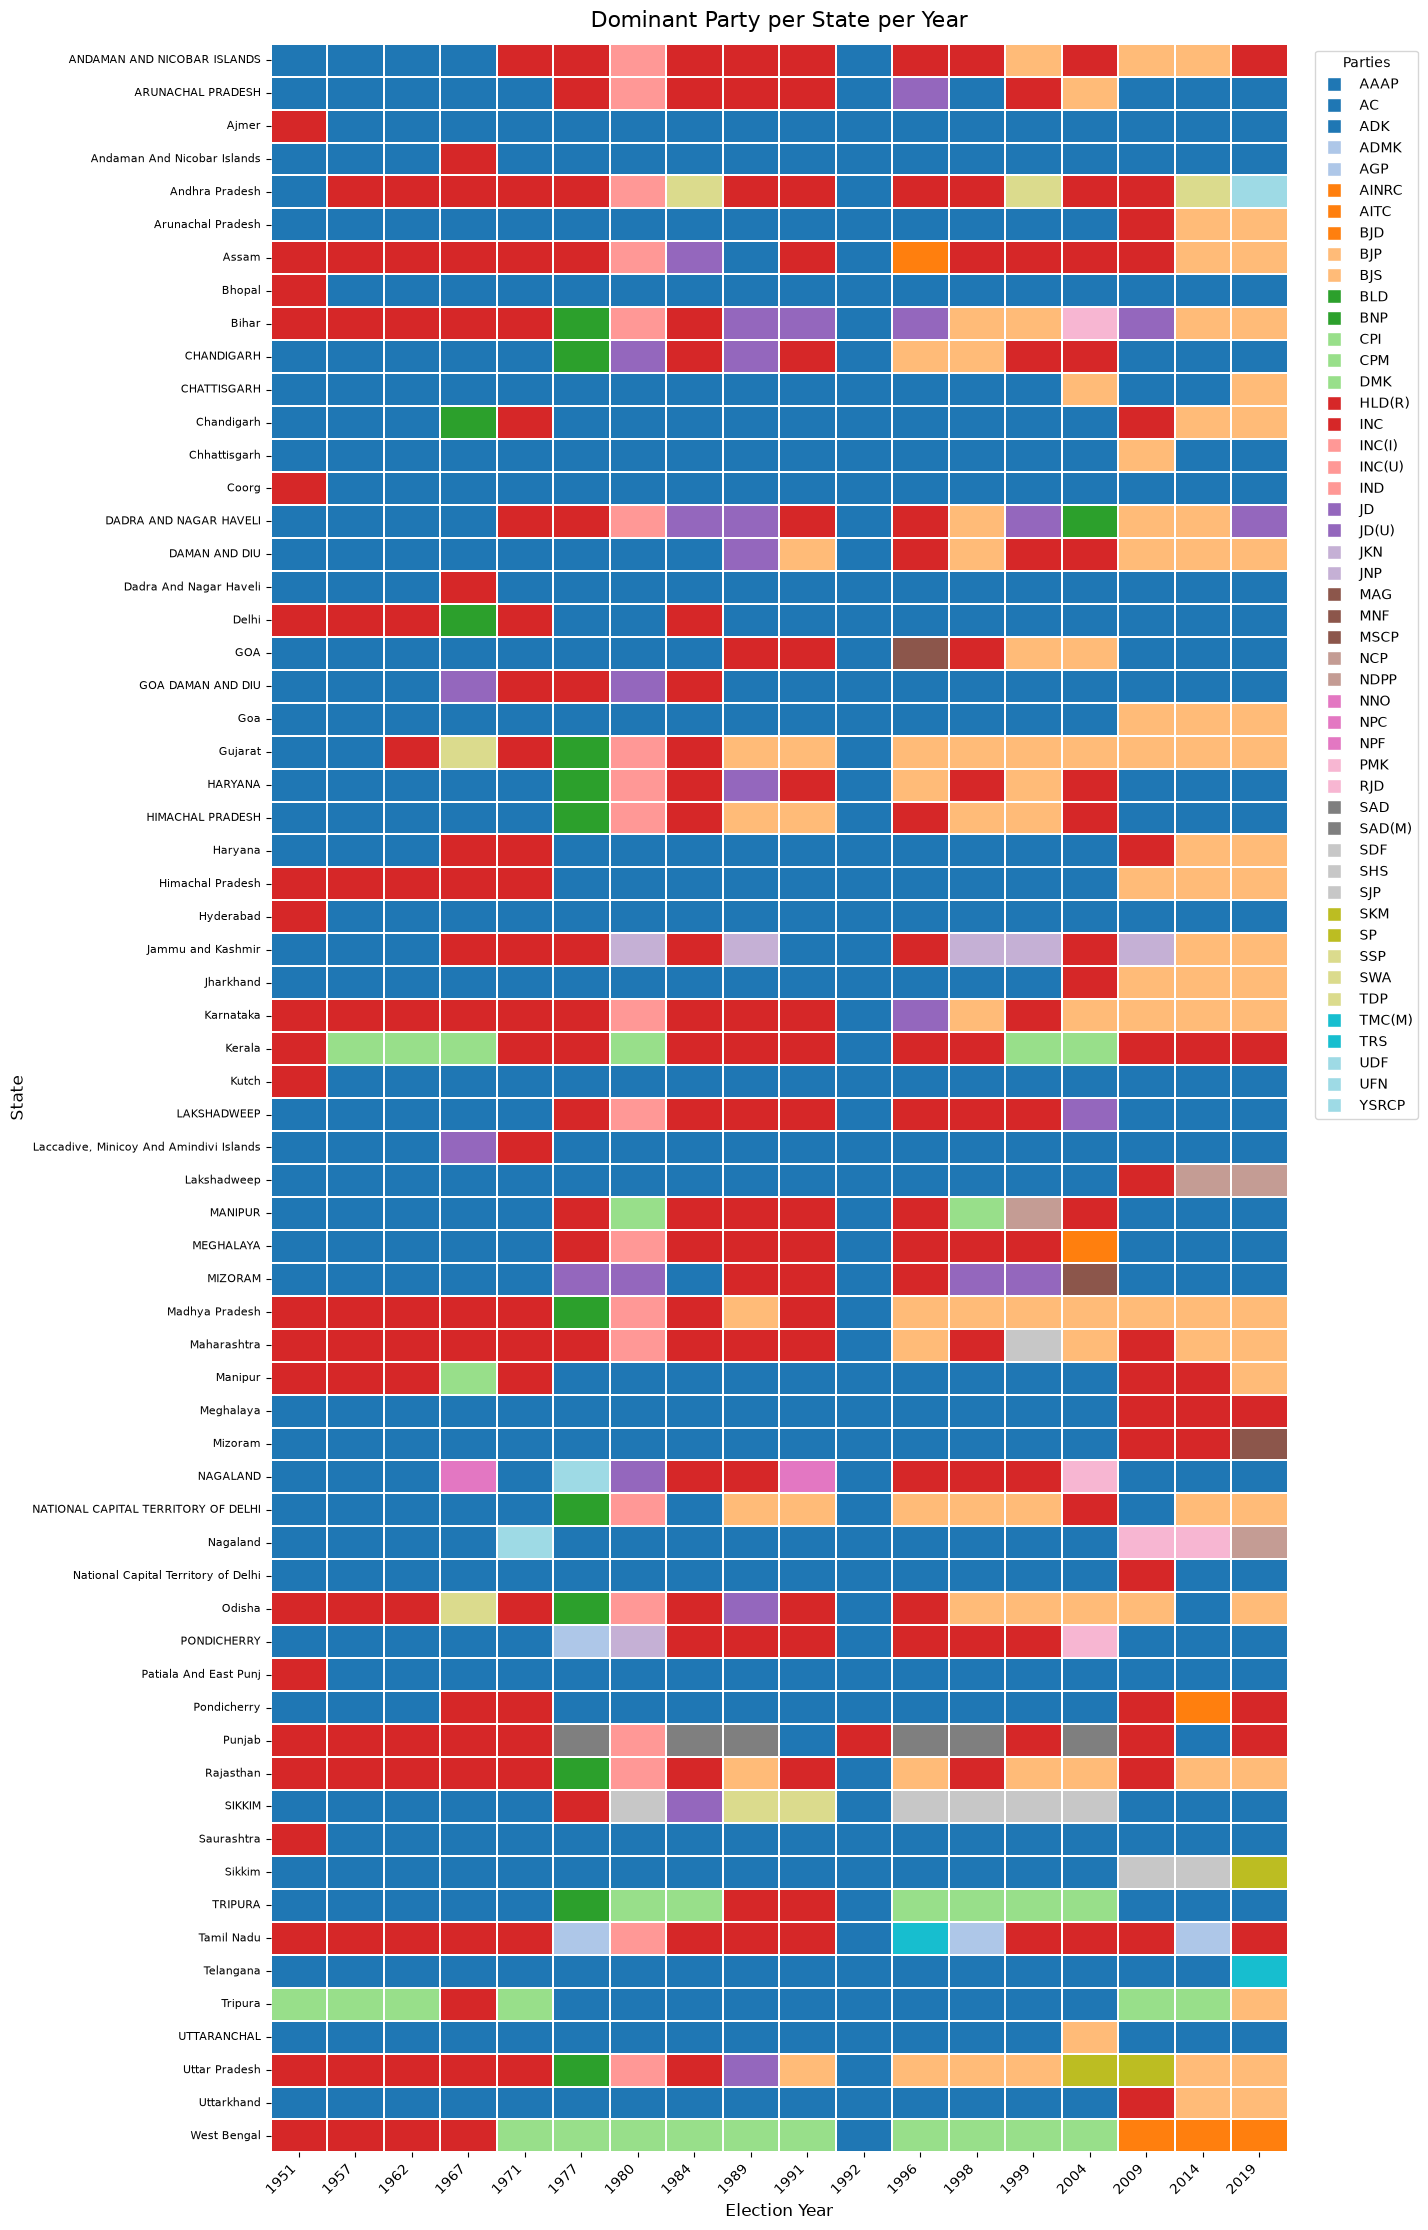

In [8]:
# Convert parties to numeric codes
unique_parties = sorted(heatmap_data.stack().dropna().unique())
party_to_num = {party: i for i, party in enumerate(unique_parties)}
numeric_heatmap = heatmap_data.map(lambda x: party_to_num.get(x, -1)).fillna(-1).astype(int)

# Keep figure size proportional to 64 rows x 18 columns
fig_width = max(14, heatmap_data.shape[1] * 0.8)   # 18 cols -> ~14.4
fig_height = max(18, heatmap_data.shape[0] * 0.35) # 64 rows -> ~22.4

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    numeric_heatmap,
    cmap="tab20",
    linewidths=0.3,
    linecolor="white",
    cbar=False,
    ax=ax
)

# Axis formatting
ax.set_title("Dominant Party per State per Year", fontsize=16, pad=12)
ax.set_xlabel("Election Year", fontsize=12)
ax.set_ylabel("State", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# Custom legend
handles = [
    Line2D([0], [0], marker='s', color='w',
           markerfacecolor=plt.cm.tab20(i / max(1, len(unique_parties)-1)),
           markersize=10, label=party)
    for i, party in enumerate(unique_parties)
]
ax.legend(handles=handles, title="Parties", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### 5.2.2 Regional clusters (North vs. South vs. East)

Categorizing individual states into broader socio-geographic zones to compare distinct regional voting behaviors.
Formula:$$R_k = \{s_1, s_2, \dots, s_n\}$$(Where region $R_k$ contains a specific subset of states $s$)

In [9]:
# Define mapping
region_dict = {
    'Uttar Pradesh': 'North', 'Bihar': 'North', 
    'Tamil Nadu': 'South', 'Kerala': 'South',
    'West Bengal': 'East', 'Odisha': 'East'
}

# Apply mapping 
df_features['region'] = df_features['state_canonical'].map(region_dict)

# Analyze average fragmentation by region 
regional_enp = df_features.groupby(['region', 'election_year_clean'])['fragmentation_index'].mean().reset_index()

regional_enp

,region,election_year_clean,fragmentation_index
0,East,1951,inf
1,East,1957,3.515692
2,East,1962,inf
3,East,1967,2.811336
4,East,1971,3.346004
5,East,1977,2.248161
6,East,1980,25.249130
7,East,1984,2.358172
8,East,1989,2.228025
9,East,1991,2.708268


## 5.3 Distribution analysis

### 5.3.1 Party size distributions

A statistical evaluation to determine if the distribution of party sizes (measured by votes received) follows a highly skewed power-law or log-normal distribution, characterized by a few giant parties and a massive tail of marginal parties.Formula:$$P(x) \propto x^{-\alpha}$$(Power-law probability density function, where $x$ is the party size and $\alpha$ is the scaling parameter)

Saved chart to ../reports/charts/Log-Normal_Distribution_of_Party_Sizes__2019__4.png


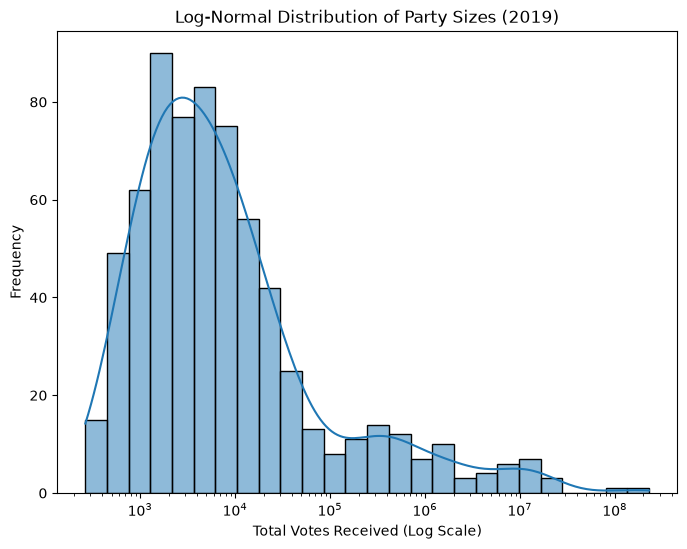

In [10]:
# Get total votes per party in a specific year
party_sizes = df_features[df_features['election_year_clean'] == 2019].groupby('party')['votes_received'].sum()

# Plot log-log distribution
plt.figure(figsize=(8, 6))
sns.histplot(party_sizes, log_scale=True, kde=True)
plt.title('Log-Normal Distribution of Party Sizes (2019)')
plt.xlabel('Total Votes Received (Log Scale)')
plt.ylabel('Frequency')
plt.show()

## 5.3.2 Distribution of volatility and fragmentation across states

Analyzing the variance and central tendency of vote swings (volatility) and Effective Number of Parties (fragmentation) across different states to identify volatile vs. stable political theaters.Formula:$$\sigma^2_s = \frac{1}{N} \sum_{t=1}^{N} (\text{ENP}_{s,t} - \mu_{\text{ENP},s})^2$$

Saved chart to ../reports/charts/Distribution_of_Political_Fragmentation_by_State_5.png


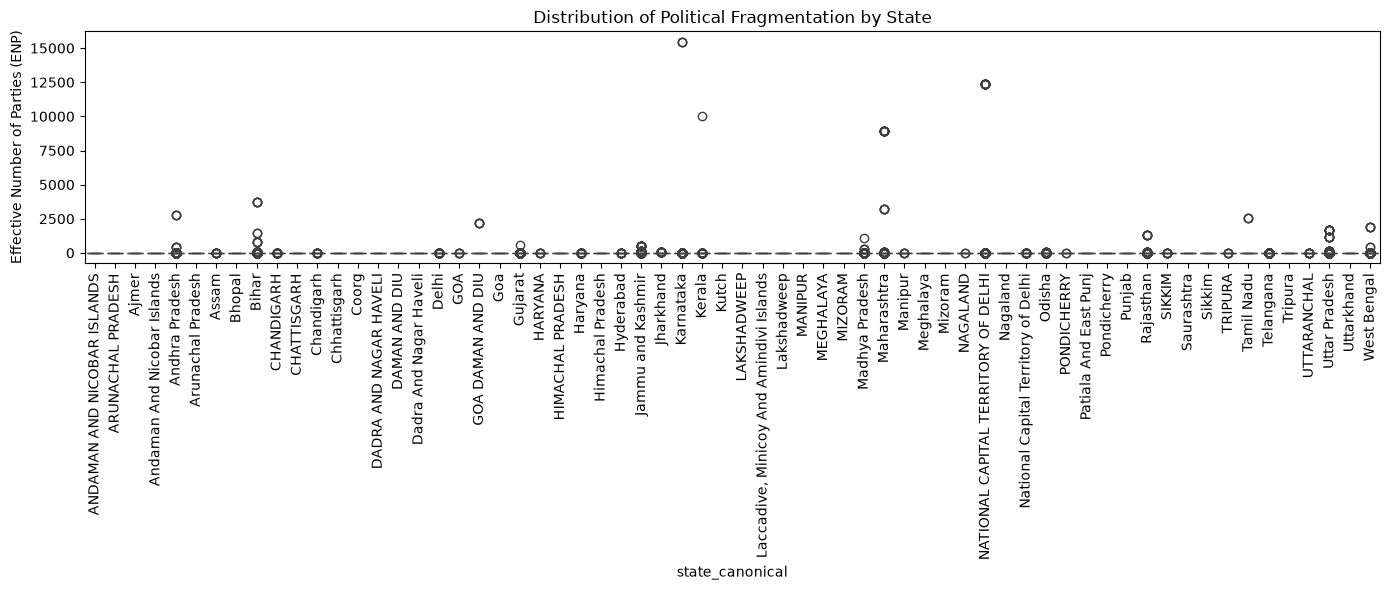

In [11]:
plt.figure(figsize=(14, 6))
# Boxplot of fragmentation index by state 
sns.boxplot(data=df_features, x='state_canonical', y='fragmentation_index')
plt.xticks(rotation=90)
plt.title('Distribution of Political Fragmentation by State')
plt.ylabel('Effective Number of Parties (ENP)')
plt.tight_layout()
plt.show()